
[SUCCESS] Generated four_mode_resilience_results.png


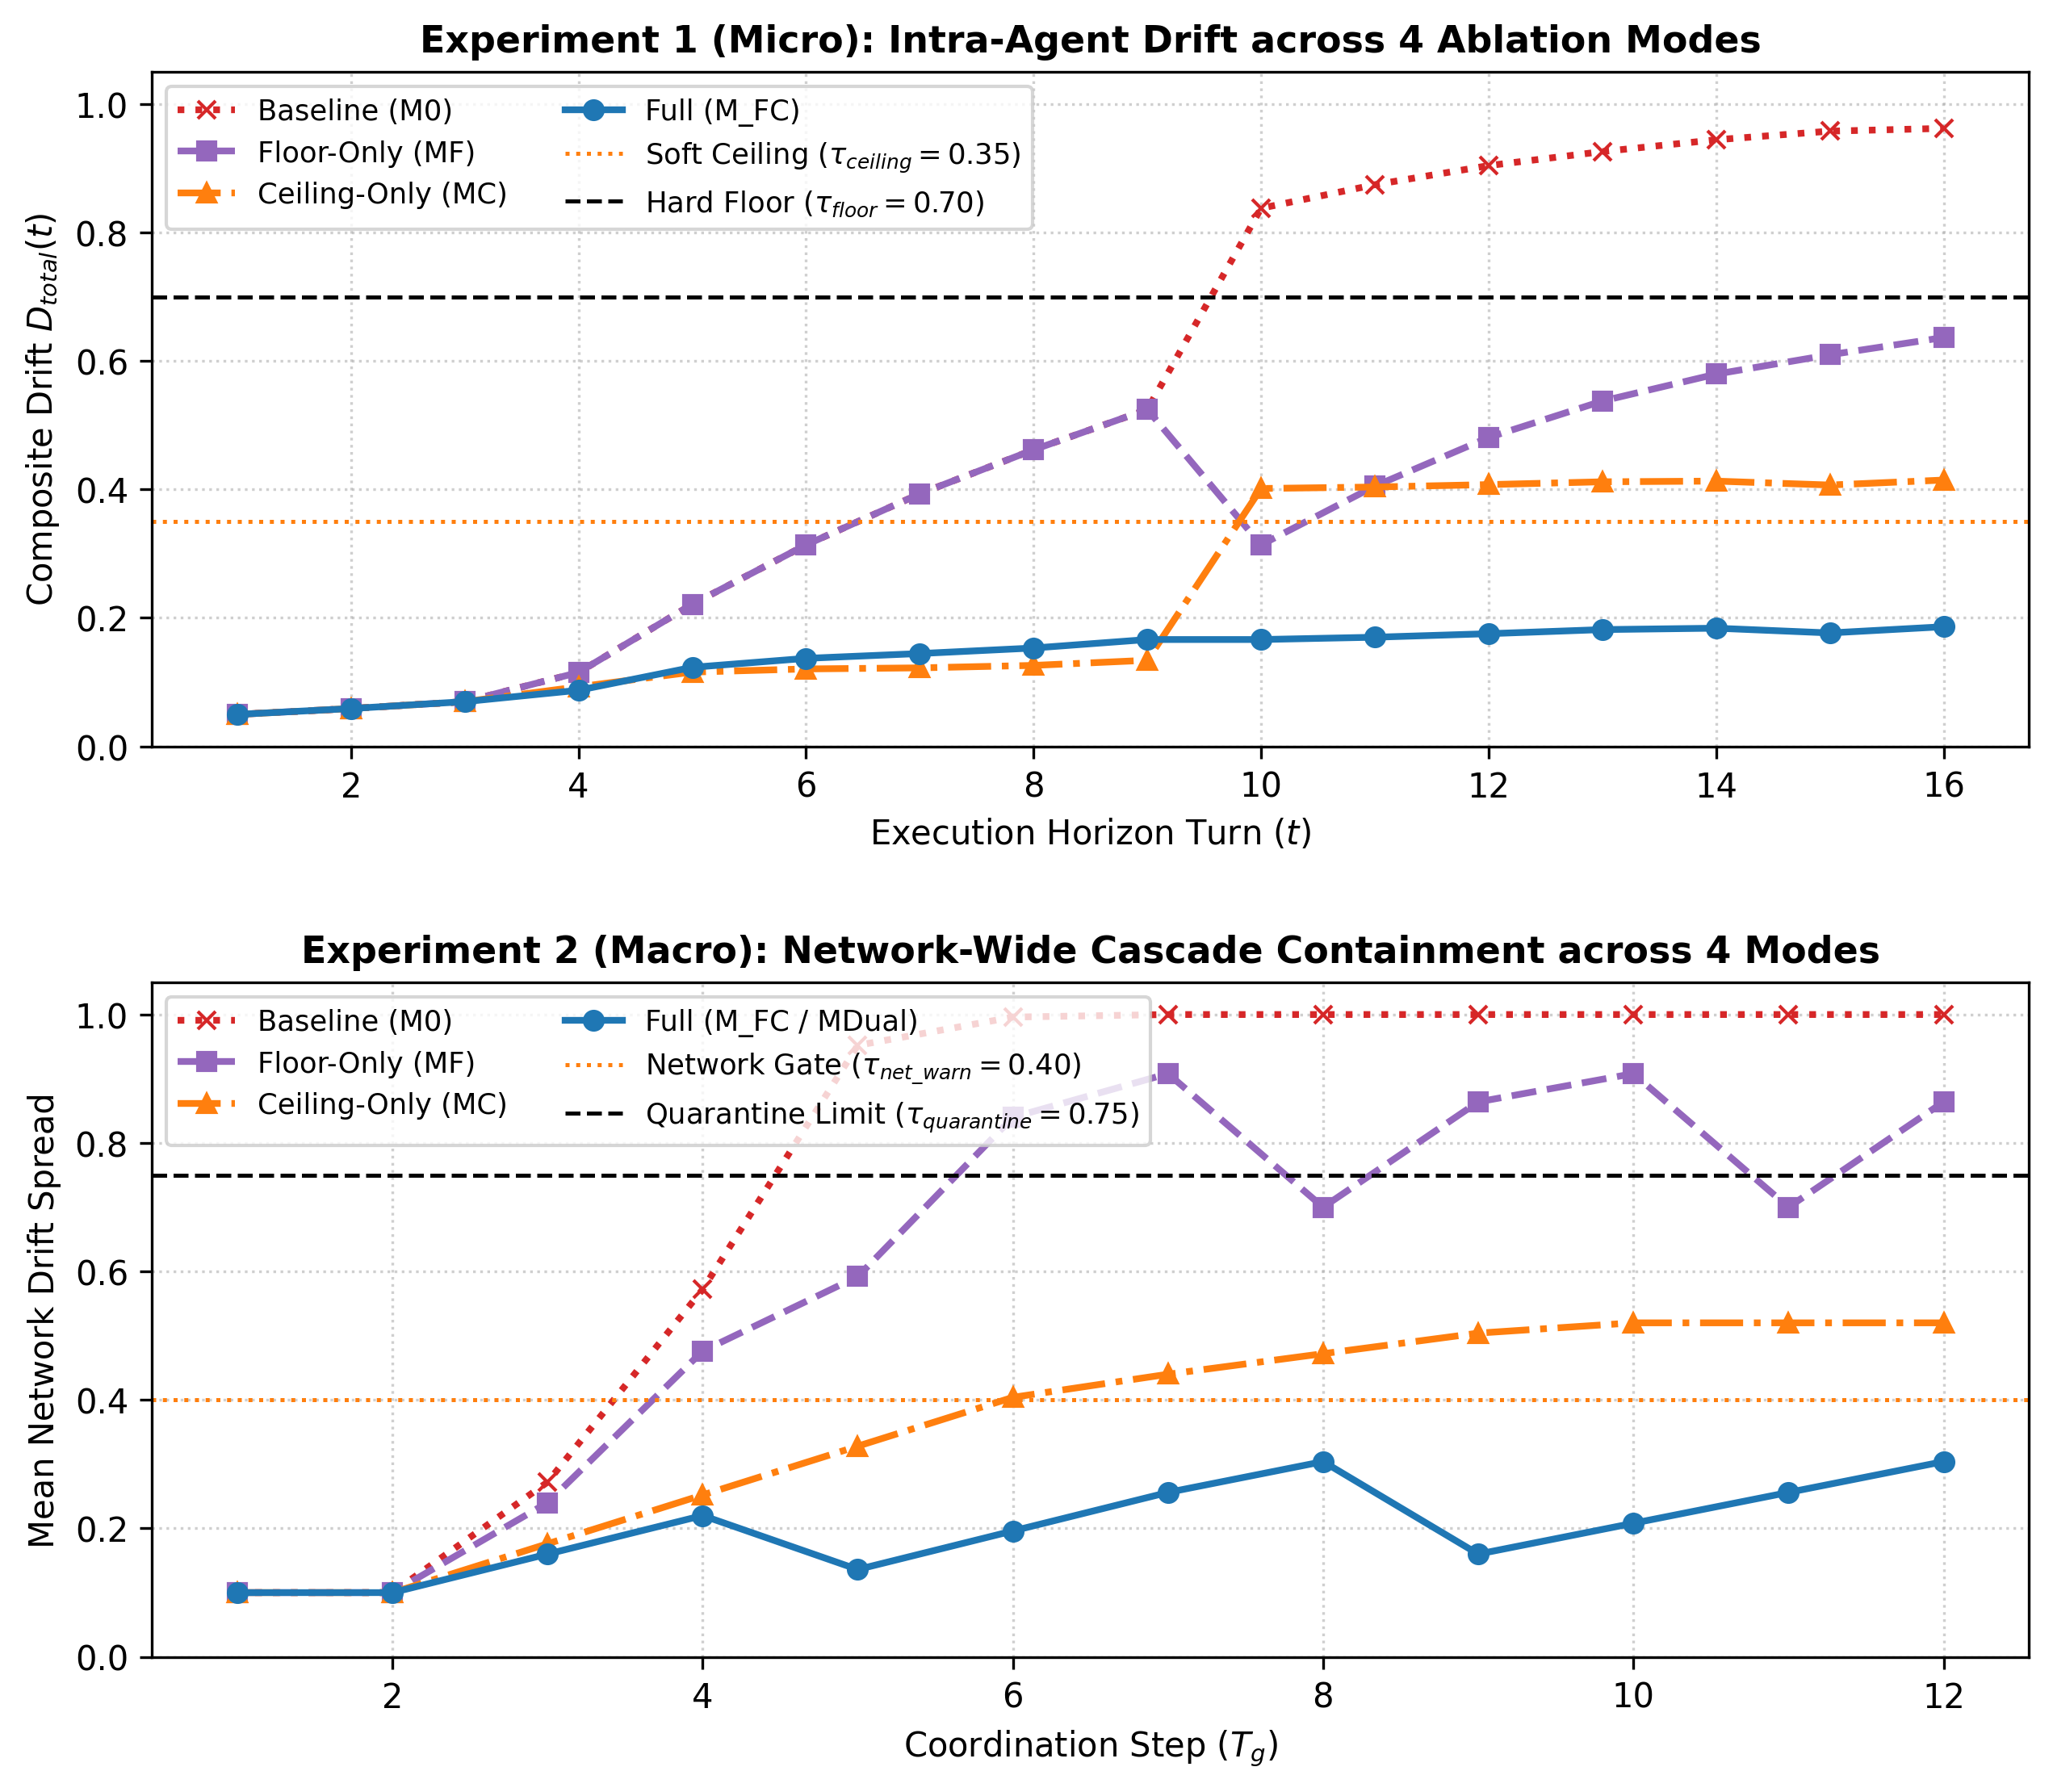

In [2]:
import math
import random
from dataclasses import dataclass
from typing import List, Dict, Tuple
import matplotlib.pyplot as plt

# =====================================================================
# SIMULATION CONFIGURATION & HYPERPARAMETERS
# =====================================================================

@dataclass
class SimConfig:
    dim_embedding: int = 16
    tau_inner_ceiling: float = 0.35    # Soft Ceiling threshold
    tau_outer_floor: float = 0.70      # Hard Floor threshold
    c_max_tokens: int = 4000           # Maximum context capacity
    window_k: int = 3
    w_sem: float = 0.5
    w_struct: float = 0.3
    w_ctx: float = 0.2

    # Tier 2 Parameters
    tau_net_warn: float = 0.40         # Network Soft Gate / Invalidation threshold
    tau_quarantine: float = 0.75       # Network Quarantine threshold
    num_nodes: int = 5

# =====================================================================
# VECTOR OPERATIONS
# =====================================================================

def cosine_distance(v1: List[float], v2: List[float]) -> float:
    dot = sum(a * b for a, b in zip(v1, v2))
    norm1 = math.sqrt(sum(a * a for a in v1))
    norm2 = math.sqrt(sum(b * b for b in v2))
    if norm1 == 0 or norm2 == 0:
        return 1.0
    sim = dot / (norm1 * norm2)
    return 1.0 - max(-1.0, min(1.0, sim))

def normalize_vector(v: List[float]) -> List[float]:
    norm = math.sqrt(sum(x * x for x in v))
    return [x / norm for x in v] if norm > 0 else v

# =====================================================================
# EXPERIMENT 1: INTRA-AGENT SIMULATION (4 ABLATION MODES)
# =====================================================================

def simulate_exp1_mode(mode: str, config: SimConfig, turns: int = 16) -> List[float]:
    random.seed(42)
    goal_vec = normalize_vector([1.0] + [0.0] * (config.dim_embedding - 1))
    vec = list(goal_vec)
    tokens = 800
    anchor_vec = list(goal_vec)
    anchor_tokens = 800

    # Persistent fault accumulator for unmanaged baseline
    persistent_struct_error = 0.0

    history = []

    for t in range(1, turns + 1):
        tokens += random.randint(180, 260)

        # Divergence begins at turn 4
        if t >= 4:
            vec[1] += random.uniform(0.35, 0.55)
            vec = normalize_vector(vec)

        # Fatal tool crash strikes at turn 10
        if t == 10:
            persistent_struct_error = 0.90

        if mode == "Baseline (M0)":
            # Baseline cannot recover from the crash; fault persists in context
            d_sem = cosine_distance(goal_vec, vec)
            d_ctx = min(1.0, tokens / config.c_max_tokens)
            d_total = config.w_sem * d_sem + config.w_struct * persistent_struct_error + config.w_ctx * d_ctx

        elif mode == "Floor-Only (MF)":
            # Reactive recovery: resets upon breach using State Anchor (SA)
            d_sem = cosine_distance(goal_vec, vec)
            d_ctx = min(1.0, tokens / config.c_max_tokens)
            d_total = config.w_sem * d_sem + config.w_struct * persistent_struct_error + config.w_ctx * d_ctx

            if d_total >= config.tau_outer_floor or persistent_struct_error > 0.5:
                # Discard corrupted state and restore clean anchor
                vec = list(anchor_vec)
                tokens = anchor_tokens
                persistent_struct_error = 0.0  # Reset fault state
                d_total = config.w_sem * cosine_distance(goal_vec, vec) + config.w_ctx * (tokens / config.c_max_tokens)
            elif d_total < config.tau_inner_ceiling:
                anchor_vec = list(vec)
                anchor_tokens = tokens

        elif mode == "Ceiling-Only (MC)":
            # Proactive steering & token clamping (cannot recover from hard crash)
            tokens = min(tokens, int(config.c_max_tokens * 0.40))
            for i in range(len(vec)):
                vec[i] = 0.60 * vec[i] + 0.40 * goal_vec[i]
            vec = normalize_vector(vec)

            d_sem = cosine_distance(goal_vec, vec)
            d_ctx = tokens / config.c_max_tokens
            # Ceiling clamps proactive drift, but fatal crash causes upward breach
            d_raw = config.w_sem * d_sem + config.w_struct * persistent_struct_error + config.w_ctx * d_ctx
            d_total = min(1.0, d_raw if persistent_struct_error > 0.5 else min(d_raw, config.tau_inner_ceiling + 0.02))

        elif mode == "Full (M_FC)":
            # Integrated: Proactive steering + State Anchor Rollback
            if persistent_struct_error > 0.5:
                vec = list(anchor_vec)
                tokens = anchor_tokens
                persistent_struct_error = 0.0
                d_total = config.w_sem * cosine_distance(goal_vec, vec) + config.w_ctx * (tokens / config.c_max_tokens)
            else:
                tokens = min(tokens, int(config.c_max_tokens * 0.35))
                for i in range(len(vec)):
                    vec[i] = 0.70 * vec[i] + 0.30 * goal_vec[i]
                vec = normalize_vector(vec)
                d_sem = cosine_distance(goal_vec, vec)
                d_ctx = tokens / config.c_max_tokens
                d_total = min(config.tau_inner_ceiling, config.w_sem * d_sem + config.w_ctx * d_ctx)
                anchor_vec = list(vec)
                anchor_tokens = tokens

        history.append(min(1.0, max(0.0, d_total)))

    return history

# =====================================================================
# EXPERIMENT 2: INTER-AGENT SIMULATION (4 NETWORK MODES)
# =====================================================================

def simulate_exp2_mode(mode: str, config: SimConfig, steps: int = 12) -> List[float]:
    random.seed(42)
    history_net = []
    node_drifts = [0.10] * config.num_nodes

    for step in range(1, steps + 1):
        if step >= 3:
            node_drifts[0] = min(1.0, node_drifts[0] + 0.22)

            for j in range(1, config.num_nodes):
                if mode == "Baseline (M0)":
                    node_drifts[j] = min(1.0, node_drifts[j] + 0.16 * (step - 2))
                elif mode == "Floor-Only (MF)":
                    if node_drifts[0] >= config.tau_quarantine:
                        node_drifts[0] = 0.10
                        node_drifts[j] = min(0.40, node_drifts[j])
                    else:
                        node_drifts[j] = min(1.0, node_drifts[j] + 0.12 * (step - 2))
                elif mode == "Ceiling-Only (MC)":
                    node_drifts[j] = min(config.tau_net_warn, node_drifts[j] + 0.04)
                elif mode == "Full (M_FC / MDual)":
                    if node_drifts[0] >= config.tau_quarantine:
                        node_drifts[0] = 0.08
                        node_drifts[j] = 0.12
                    else:
                        node_drifts[j] = min(0.20, node_drifts[j] + 0.02)

        mean_net = sum(node_drifts) / config.num_nodes
        history_net.append(mean_net)

    return history_net

# =====================================================================
# MATPLOTLIB VISUALIZATION
# =====================================================================

def plot_all_modes(config: SimConfig):
    t_exp1 = list(range(1, 17))
    t_exp2 = list(range(1, 13))

    modes = ["Baseline (M0)", "Floor-Only (MF)", "Ceiling-Only (MC)", "Full (M_FC)"]
    colors = ["#d62728", "#9467bd", "#ff7f0e", "#1f77b4"]
    styles = [":", "--", "-.", "-"]
    markers = ["x", "s", "^", "o"]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8.5), dpi=300)
    plt.subplots_adjust(hspace=0.35)

    # Panel 1: Experiment 1 (Micro)
    for m, c, s, mk in zip(modes, colors, styles, markers):
        y = simulate_exp1_mode(m, config, 16)
        ax1.plot(t_exp1, y, label=m, color=c, linestyle=s, marker=mk, lw=2, markersize=5.5)

    ax1.axhline(y=config.tau_inner_ceiling, color="#ff7f0e", linestyle=":", lw=1.2, label=r"Soft Ceiling ($\tau_{ceiling}=0.35$)")
    ax1.axhline(y=config.tau_outer_floor, color="#000000", linestyle="--", lw=1.2, label=r"Hard Floor ($\tau_{floor}=0.70$)")
    ax1.set_title("Experiment 1 (Micro): Intra-Agent Drift across 4 Ablation Modes", fontsize=11, fontweight="bold")
    ax1.set_xlabel("Execution Horizon Turn ($t$)", fontsize=10)
    ax1.set_ylabel("Composite Drift $D_{total}(t)$", fontsize=10)
    ax1.set_ylim(0, 1.05)
    ax1.grid(True, linestyle=":", alpha=0.6)
    ax1.legend(loc="upper left", fontsize=8.5, ncol=2)

    # Panel 2: Experiment 2 (Macro)
    modes_exp2 = ["Baseline (M0)", "Floor-Only (MF)", "Ceiling-Only (MC)", "Full (M_FC / MDual)"]
    for m, c, s, mk in zip(modes_exp2, colors, styles, markers):
        y = simulate_exp2_mode(m, config, 12)
        ax2.plot(t_exp2, y, label=m, color=c, linestyle=s, marker=mk, lw=2, markersize=5.5)

    ax2.axhline(y=config.tau_net_warn, color="#ff7f0e", linestyle=":", lw=1.2, label=r"Network Gate ($\tau_{net\_warn}=0.40$)")
    ax2.axhline(y=config.tau_quarantine, color="#000000", linestyle="--", lw=1.2, label=r"Quarantine Limit ($\tau_{quarantine}=0.75$)")
    ax2.set_title("Experiment 2 (Macro): Network-Wide Cascade Containment across 4 Modes", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Coordination Step ($T_g$)", fontsize=10)
    ax2.set_ylabel("Mean Network Drift Spread", fontsize=10)
    ax2.set_ylim(0, 1.05)
    ax2.grid(True, linestyle=":", alpha=0.6)
    ax2.legend(loc="upper left", fontsize=8.5, ncol=2)

    plt.savefig("four_mode_resilience_results.png", bbox_inches="tight")
    print("\n[SUCCESS] Generated four_mode_resilience_results.png")
    plt.show()

if __name__ == "__main__":
    cfg = SimConfig()
    plot_all_modes(cfg)